In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv('/content/results.csv')
df.head()


,now,published_at,price,house_type,size,living_size,price_m2,property_legal_document,rooms,toilets,...,size_unit,direction,commercial_type,floornumber,block,balconydirection,unitnumber,apartment_feature,property_back_condition,street_id
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,"7,95 tỷ","Nhà ngõ, hẻm",34 m²,34 m²,"233,82 triệu/m²",Đã có sổ,3 phòng,4 phòng,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,"13,8 tỷ","Nhà ngõ, hẻm",65 m²,NaN,"212,31 triệu/m²",Đã có sổ,5 phòng,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,"11,5 tỷ","Nhà ngõ, hẻm",44 m²,100 m²,"261,36 triệu/m²",Đã có sổ,4 phòng,3 phòng,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-10-03T23:43:27.715299,Cập nhật 8 ngày trước,"8,7 tỷ",NaN,90 m²,NaN,"96,67 triệu/m²",Sổ hồng riêng,3 phòng,2 phòng,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7 tỷ,"Nhà ngõ, hẻm",38 m²,NaN,"184,21 triệu/m²",Đã có sổ,3 phòng,3 phòng,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Tính tỷ lệ giá trị thiếu của từng cột
missing_ratio = df.isna().mean() * 100
missing_ratio

,0
now,0.000000
published_at,0.000000
price,0.000000
house_type,24.116011
size,0.000000
living_size,64.004768
price_m2,0.000000
property_legal_document,0.000000
rooms,15.295987
toilets,46.642829


In [ ]:
cols_to_drop = missing_ratio[missing_ratio > 50].index
df = df.drop(columns=cols_to_drop)


In [ ]:
missing_ratio = df.isna().mean() * 100
missing_ratio

,0
now,0.000000
published_at,0.000000
price,0.000000
house_type,24.116011
size,0.000000
price_m2,0.000000
property_legal_document,0.000000
rooms,15.295987
toilets,46.642829
furnishing_sell,49.741756


In [ ]:
df.head()

,now,published_at,price,house_type,size,price_m2,property_legal_document,rooms,toilets,furnishing_sell,floors
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,"7,95 tỷ","Nhà ngõ, hẻm",34 m²,"233,82 triệu/m²",Đã có sổ,3 phòng,4 phòng,Nội thất cao cấp,5.0
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,"13,8 tỷ","Nhà ngõ, hẻm",65 m²,"212,31 triệu/m²",Đã có sổ,5 phòng,NaN,Nội thất đầy đủ,NaN
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,"11,5 tỷ","Nhà ngõ, hẻm",44 m²,"261,36 triệu/m²",Đã có sổ,4 phòng,3 phòng,Nội thất đầy đủ,3.0
3,2025-10-03T23:43:27.715299,Cập nhật 8 ngày trước,"8,7 tỷ",NaN,90 m²,"96,67 triệu/m²",Sổ hồng riêng,3 phòng,2 phòng,NaN,NaN
4,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7 tỷ,"Nhà ngõ, hẻm",38 m²,"184,21 triệu/m²",Đã có sổ,3 phòng,3 phòng,NaN,NaN


In [ ]:
# Đếm số cột bị thiếu (NaN) trong mỗi hàng
df['missing_count'] = df.isna().sum(axis=1)

# Đếm tần suất xuất hiện của từng mức độ thiếu
missing_distribution = df['missing_count'].value_counts().sort_index()
missing_distribution

,count
missing_count,
0,823
1,440
2,395
3,429
4,53
5,377


In [ ]:
df = df[df['missing_count'] <= 2].copy()
len(df)

1658

In [ ]:
missing_ratio = df.isna().mean() * 100
missing_ratio

,0
now,0.000000
published_at,0.000000
price,0.000000
house_type,7.720145
size,0.000000
price_m2,0.000000
property_legal_document,0.000000
rooms,0.000000
toilets,21.049457
furnishing_sell,25.090470


In [ ]:
def convert_price(value):
    value = str(value).strip().lower().replace(',', '.')
    if 'tỷ' in value:
        return float(value.replace('tỷ', '').strip())
    elif 'triệu' in value:
        return float(value.replace('triệu', '').strip()) / 1000
    else:
        return None

df['price'] = df['price'].apply(convert_price)


In [ ]:
def clean_numeric_column(series):
    series = (
        series.astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype(float)
    )
    return series

for col in ['rooms', 'toilets','size','price_m2']:
    df[col] = clean_numeric_column(df[col])

In [ ]:
df.head()

,now,published_at,price,house_type,size,price_m2,property_legal_document,rooms,toilets,furnishing_sell,floors,missing_count
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,7.95,"Nhà ngõ, hẻm",34.0,233.0,Đã có sổ,3.0,4.0,Nội thất cao cấp,5.0,0
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,13.80,"Nhà ngõ, hẻm",65.0,212.0,Đã có sổ,5.0,NaN,Nội thất đầy đủ,NaN,2
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,11.50,"Nhà ngõ, hẻm",44.0,261.0,Đã có sổ,4.0,3.0,Nội thất đầy đủ,3.0,0
4,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7.00,"Nhà ngõ, hẻm",38.0,184.0,Đã có sổ,3.0,3.0,NaN,NaN,2
7,2025-10-03T23:43:33.133247,Cập nhật 4 ngày trước,5.00,"Nhà ngõ, hẻm",32.0,156.0,Đã có sổ,3.0,4.0,NaN,4.0,1


In [ ]:
numeric_cols = ['price', 'size', 'price_m2', 'rooms', 'toilets', 'floors']

for col in numeric_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

cat_cols = ['house_type', 'property_legal_document', 'furnishing_sell']

for col in cat_cols:
    if df[col].isna().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

df = df.drop(columns=['missing_count','price_m2'])
df.isna().mean() * 100


,0
now,0.0
published_at,0.0
price,0.0
house_type,0.0
size,0.0
property_legal_document,0.0
rooms,0.0
toilets,0.0
furnishing_sell,0.0
floors,0.0


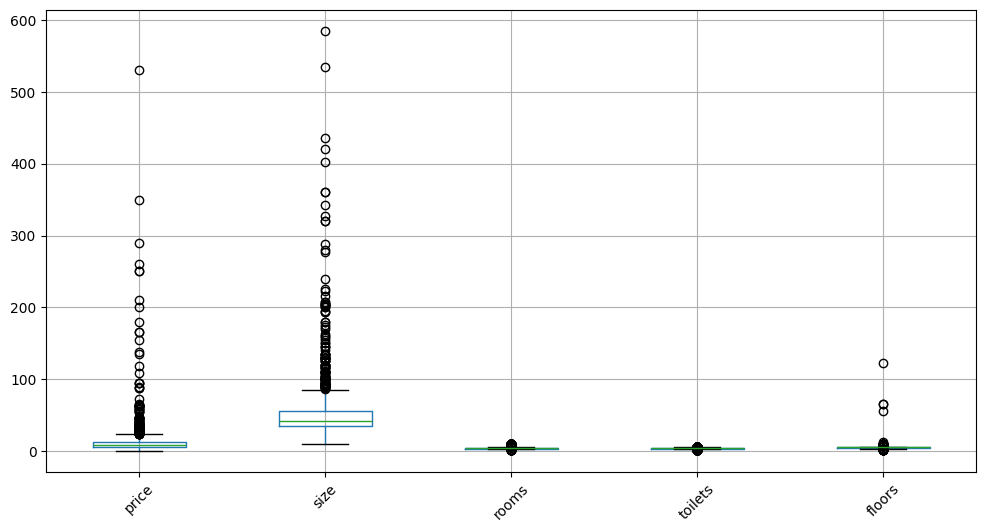

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def remove_outliers_iqr(df, col):
    df_out = df.copy()
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
    df_out = df_out.reset_index(drop=True)
    return df_out
df_cleaned=df.copy()
df_cleaned['price_per_size'] = df_cleaned['price'] / df_cleaned['size']
df_cleaned = remove_outliers_iqr(df_cleaned, 'floors')
df_cleaned = remove_outliers_iqr(df_cleaned, 'price_per_size')
df_cleaned = remove_outliers_iqr(df_cleaned, 'size')
df_cleaned = remove_outliers_iqr(df_cleaned, 'price')


print(f"Số dòng trước khi loại bỏ outlier: {len(df)}")
print(f"Số dòng sau khi loại bỏ outlier: {len(df_cleaned)}")

Số dòng trước khi loại bỏ outlier: 1658
Số dòng sau khi loại bỏ outlier: 1251


In [ ]:
df_cleaned.head()

,now,published_at,price,house_type,size,property_legal_document,rooms,toilets,furnishing_sell,floors,price_per_size
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,7.95,"Nhà ngõ, hẻm",34.0,Đã có sổ,3.0,4.0,Nội thất cao cấp,5.0,0.233824
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,13.80,"Nhà ngõ, hẻm",65.0,Đã có sổ,5.0,4.0,Nội thất đầy đủ,5.0,0.212308
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,11.50,"Nhà ngõ, hẻm",44.0,Đã có sổ,4.0,3.0,Nội thất đầy đủ,3.0,0.261364
3,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7.00,"Nhà ngõ, hẻm",38.0,Đã có sổ,3.0,3.0,Nội thất đầy đủ,5.0,0.184211
4,2025-10-03T23:43:33.133247,Cập nhật 4 ngày trước,5.00,"Nhà ngõ, hẻm",32.0,Đã có sổ,3.0,4.0,Nội thất đầy đủ,4.0,0.156250


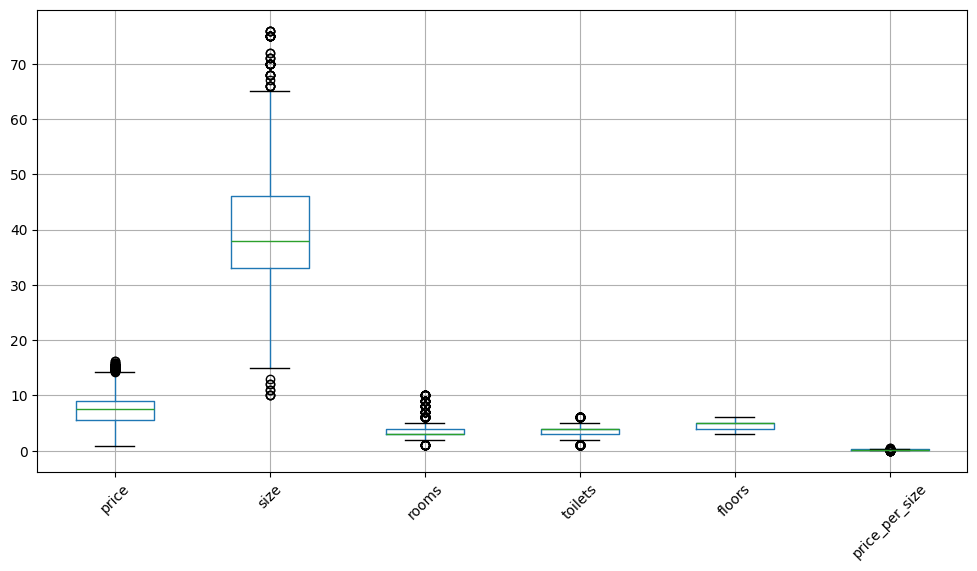

In [ ]:
plt.figure(figsize=(12, 6))
df_cleaned.boxplot()
plt.xticks(rotation=45)
plt.show()


In [ ]:
df_cleaned

,now,published_at,price,house_type,size,property_legal_document,rooms,toilets,furnishing_sell,floors,price_per_size
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,7.95,"Nhà ngõ, hẻm",34.0,Đã có sổ,3.0,4.0,Nội thất cao cấp,5.0,0.233824
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,13.80,"Nhà ngõ, hẻm",65.0,Đã có sổ,5.0,4.0,Nội thất đầy đủ,5.0,0.212308
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,11.50,"Nhà ngõ, hẻm",44.0,Đã có sổ,4.0,3.0,Nội thất đầy đủ,3.0,0.261364
3,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7.00,"Nhà ngõ, hẻm",38.0,Đã có sổ,3.0,3.0,Nội thất đầy đủ,5.0,0.184211
4,2025-10-03T23:43:33.133247,Cập nhật 4 ngày trước,5.00,"Nhà ngõ, hẻm",32.0,Đã có sổ,3.0,4.0,Nội thất đầy đủ,4.0,0.156250
...,...,...,...,...,...,...,...,...,...,...,...
1246,2025-10-04T12:46:06.176375,Cập nhật 9 ngày trước,8.35,"Nhà ngõ, hẻm",45.0,Đã có sổ,4.0,4.0,Nội thất cao cấp,5.0,0.185556
1247,2025-10-04T12:46:09.347694,Cập nhật 9 ngày trước,7.90,"Nhà ngõ, hẻm",36.0,Đã có sổ,4.0,4.0,Nội thất đầy đủ,4.0,0.219444
1248,2025-10-04T12:46:10.663161,Cập nhật 9 ngày trước,12.10,"Nhà ngõ, hẻm",39.0,Đã có sổ,3.0,6.0,Nội thất cao cấp,6.0,0.310256
1249,2025-10-04T12:46:19.298759,Cập nhật 9 ngày trước,7.65,"Nhà ngõ, hẻm",42.0,Đã có sổ,3.0,4.0,Nội thất đầy đủ,5.0,0.182143


In [ ]:
df_cleaned.drop(columns=['price_per_size'],inplace=True)
df_cleaned.to_csv("df_cleaned.csv", index=False, encoding="utf-8-sig")

/tmp/ipython-input-602478526.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


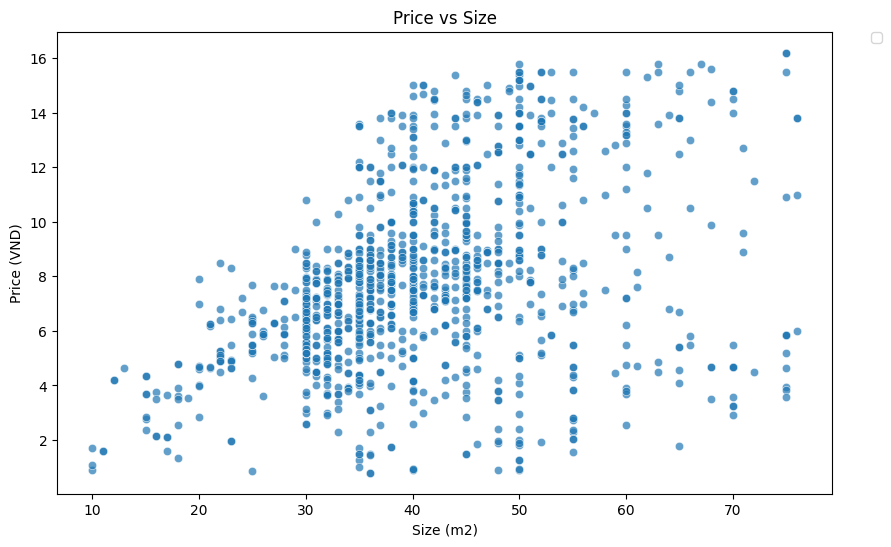

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Giả sử df_cleanedw đã có sẵn các cột: published_at, price, house_type, size, property_legal_do

# Scatter plot price vs size
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_cleaned,
    x='size',
    y='price',
    alpha=0.7
)

plt.title('Price vs Size')
plt.xlabel('Size (m2)')
plt.ylabel('Price (VND)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
